In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Kaggle 必备工具
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 加载数据 (请确保路径正确)
df = pd.read_csv('your_path.cleaned_superstore.csv', encoding='windows-1252')

In [2]:
# 1. 加载数据
# 注意：根据你的 dtypes，部分数值列现在是 str，我们需要先转换
numeric_cols_to_fix = ['Sales', 'Quantity', 'Discount']
for col in numeric_cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [3]:
# 2. 特征工程与 180 天留存标签定义 (180-Day Retention Window)
# A. 确保日期是 datetime 格式 (转换一下，方便算天数)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# B. 获取每个客户的所有唯一订单日期，并按顺序排名
# 注意：我们要找的是“第二次下单的时间”
order_ranks = df[['Customer ID', 'Order ID', 'Order_Date']].drop_duplicates()
order_ranks['rank'] = order_ranks.sort_values(['Customer ID', 'Order_Date']).groupby('Customer ID').cumcount() + 1

# C. 提取首单日期 (rank 1) 和 次单日期 (rank 2)
first_orders_time = order_ranks[order_ranks['rank'] == 1][['Customer ID', 'Order_Date']].rename(columns={'Order_Date': 'First_Date'})
second_orders_time = order_ranks[order_ranks['rank'] == 2][['Customer ID', 'Order_Date']].rename(columns={'Order_Date': 'Second_Date'})

# D. 合并并计算时间差 (Gap)
retention_logic = pd.merge(first_orders_time, second_orders_time, on='Customer ID', how='left')
retention_logic['gap'] = (retention_logic['Second_Date'] - retention_logic['First_Date']).dt.days

# E. 定义新的 Y：如果在 180 天内回来了，就是 1，否则（包括没回来的）就是 0
retention_logic['is_retained'] = ((retention_logic['gap'] > 0) & (retention_logic['gap'] <= 180)).astype(int)

# F. 获取首单的特征 (从“提取单行”改为“聚合整单”)
# a. 找到每个客户的首单日期
first_order_dates = df.groupby('Customer ID')['Order_Date'].min().reset_index()

# b. 将原始 df 与首单日期合并，筛选出首单日期的所有产品行
# 注意：此时 df_first_orders 包含了首单里的所有商品（可能是一个客户多行）
df_first_orders_all_items = pd.merge(df, first_order_dates, on=['Customer ID', 'Order_Date'])

# c. 【核心修改】按 Customer ID 分组聚合，把多行变一行，计算整单总量
df_first_orders = df_first_orders_all_items.groupby('Customer ID').agg({
    'Sales': 'sum',           # 首单总销售额
    'Quantity': 'sum',        # 首单总商品件数
    'Discount': 'mean',       # 首单平均折扣力度
    'Profit': 'sum',          # 首单总利润（为了算 Margin）
    'Region': 'first',        # 地理区域（同一单通常一致，取第一个）
    'Segment': 'first',       # 客户分段（同一客户一致，取第一个）
    'Ship Mode': 'first',     # 配送模式（同一单通常一致，取第一个）
    'Sub-Category': 'first'   # 子类别（首单可能有多个，取第一个作为代表，或选销量最大的）
}).reset_index()

# d. 【数学修正】重新计算整单的 Profit_Margin，而不是对每一行的 Margin 求平均
# 这样能更准确地反映这一单是“大赚”还是“大亏”
df_first_orders['Profit_Margin'] = df_first_orders['Profit'] / df_first_orders['Sales']
df_first_orders.replace([np.inf, -np.inf], np.nan, inplace=True)
df_first_orders['Profit_Margin'] = df_first_orders['Profit_Margin'].fillna(0)

# G. 最终合并特征与新的标签
final_df = pd.merge(
    df_first_orders, 
    retention_logic[['Customer ID', 'is_retained']], 
    on='Customer ID',
    how='inner'
)

# 打印一下结果看看，确保每个客户只有一行，且 Sales 是总和
print(f"最终特征集行数: {final_df.shape[0]} (应等于唯一客户数)")
print(final_df[['Customer ID', 'Sales', 'Profit_Margin', 'is_retained']].head())

最终特征集行数: 793 (应等于唯一客户数)
  Customer ID     Sales  Profit_Margin  is_retained
0    AA-10315   726.548       0.368073            1
1    AA-10375    16.520       0.337500            0
2    AA-10480    27.460       0.360000            0
3    AA-10645  1106.770      -0.018103            1
4    AB-10015    12.624      -0.200000            1


In [4]:
# 3. 变量选择
# 按照咱们讨论的清单，剔除 State 和不相关的 ID
numeric_features = ['Sales', 'Quantity', 'Discount', 'Profit_Margin']
categorical_features = ['Region', 'Sub-Category', 'Ship Mode', 'Segment']

X = final_df[numeric_features + categorical_features]
y = final_df['is_retained']

# 按照 Kaggle 标准：80% 学习，20% 考试
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# 4. 构建预处理 Pipeline (The Kaggle Way)

# 数值型处理：填补中位数 + 标准化
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 类别型处理：填补缺失 + One-Hot 编码
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 组合预处理逻辑
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [6]:
# 5. 定义模型与完整 Pipeline
ratio = (y_train == 0).sum() / (y_train == 1).sum()
model = XGBClassifier(n_estimators=50, learning_rate=0.05, scale_pos_weight=ratio, random_state=42, eval_metric='logloss')

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

In [7]:
# 6. 交叉验证 (Cross-Validation)
# 看看模型在未见数据上的平均表现
from sklearn.model_selection import cross_validate
scoring = ['accuracy', 'f1', 'roc_auc']
cv_results = cross_validate(clf, X_train, y_train, cv=5, scoring=scoring)

print(f"平均 Accuracy: {cv_results['test_accuracy'].mean():.4f}")
print(f"平均 F1 Score: {cv_results['test_f1'].mean():.4f}")
print(f"平均 ROC-AUC: {cv_results['test_roc_auc'].mean():.4f}")

平均 Accuracy: 0.5110
平均 F1 Score: 0.4562
平均 ROC-AUC: 0.5292


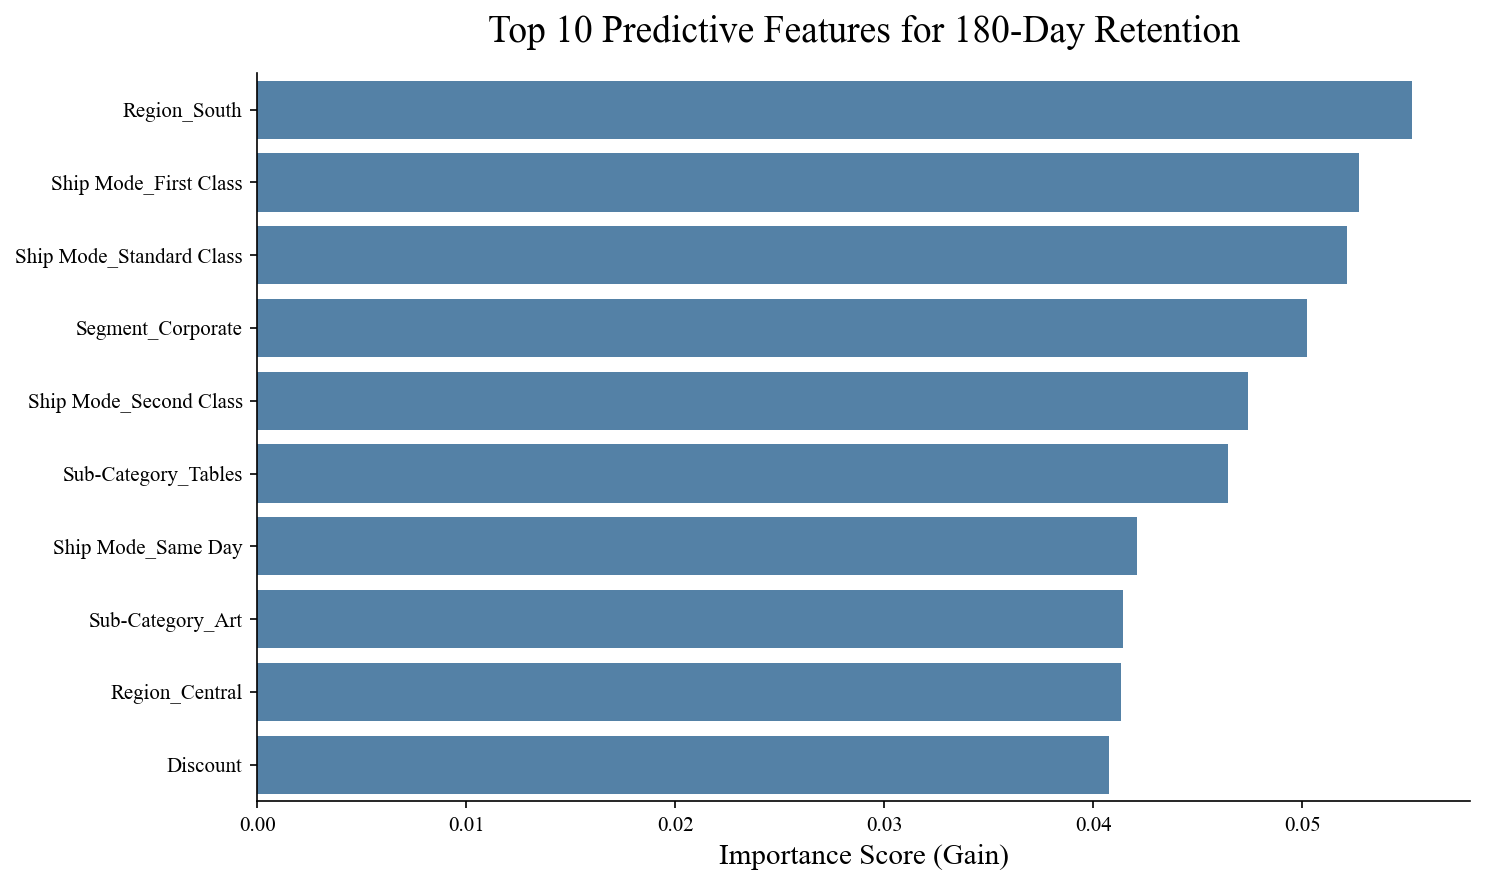

In [14]:
# 7. 训练模型并查看特征重要性 (Feature Importance)
clf.fit(X_train, y_train)

# A. 优雅地提取特征名 (适用于 Scikit-learn 1.0+)
all_feature_names = clf.named_steps['preprocessor'].get_feature_names_out()

# B. 创建 DataFrame 并清洗名称 (去掉 num__ 和 cat__ 前缀)
feature_importance_df = pd.DataFrame({
    'feature': [f.split('__')[1] for f in all_feature_names], 
    'importance': clf.named_steps['model'].feature_importances_
}).sort_values(by='importance', ascending=False)

# C. 专业绘图配置
plt.figure(figsize=(10, 6), dpi=150)
plt.rcParams["font.family"] = "Times New Roman"

# 使用深蓝色调，并去掉边框
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), color='#4682B4')

plt.title('Top 10 Predictive Features for 180-Day Retention', fontsize=18, pad=15)
plt.xlabel('Importance Score (Gain)', fontsize=14)
plt.ylabel('', fontsize=14) # 去掉纵轴标题，让特征名更显眼
sns.despine() # 去掉上方和右侧边框

plt.tight_layout()
plt.savefig('ML_Figure1_Feature_Importance.png')
plt.show()

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


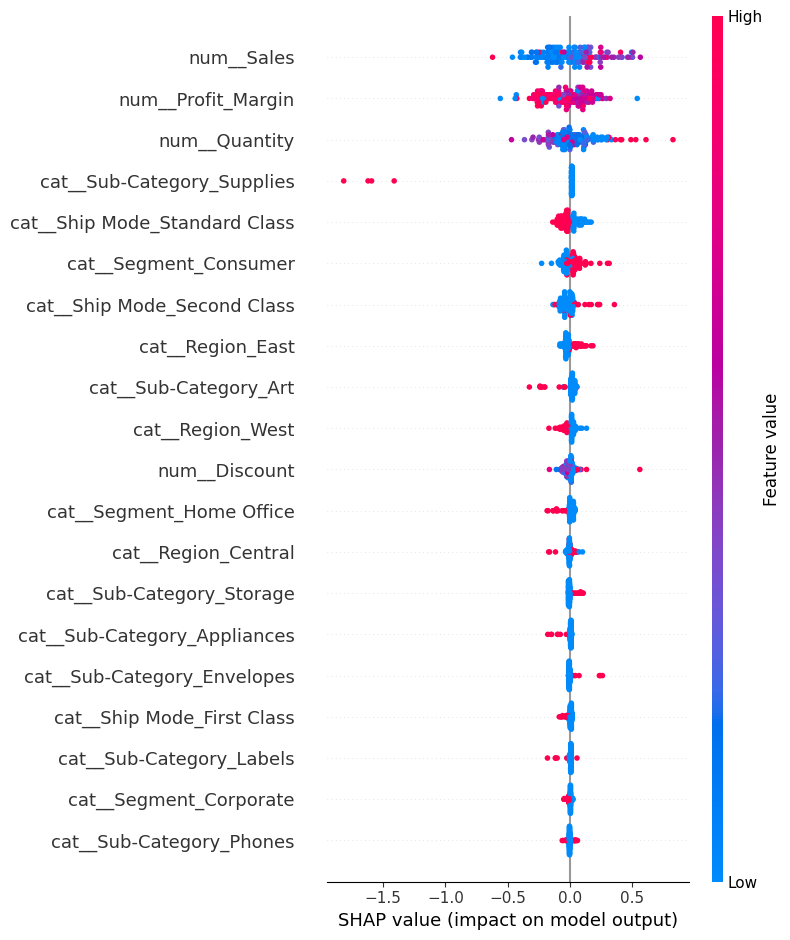

In [9]:
import shap

# 1. 创建解释器 (注意：用你 fit 好的模型)
explainer = shap.TreeExplainer(clf.named_steps['model'])

# 2. 计算验证集的 SHAP 值（需要先用预处理器转换一下 X_valid）
X_valid_transformed = clf.named_steps['preprocessor'].transform(X_valid)
# 获取特征名称（处理过后的）
feature_names = clf.named_steps['preprocessor'].get_feature_names_out()

shap_values = explainer.shap_values(X_valid_transformed)

# 3. 画出 Summary Plot
shap.summary_plot(shap_values, X_valid_transformed, feature_names=feature_names)

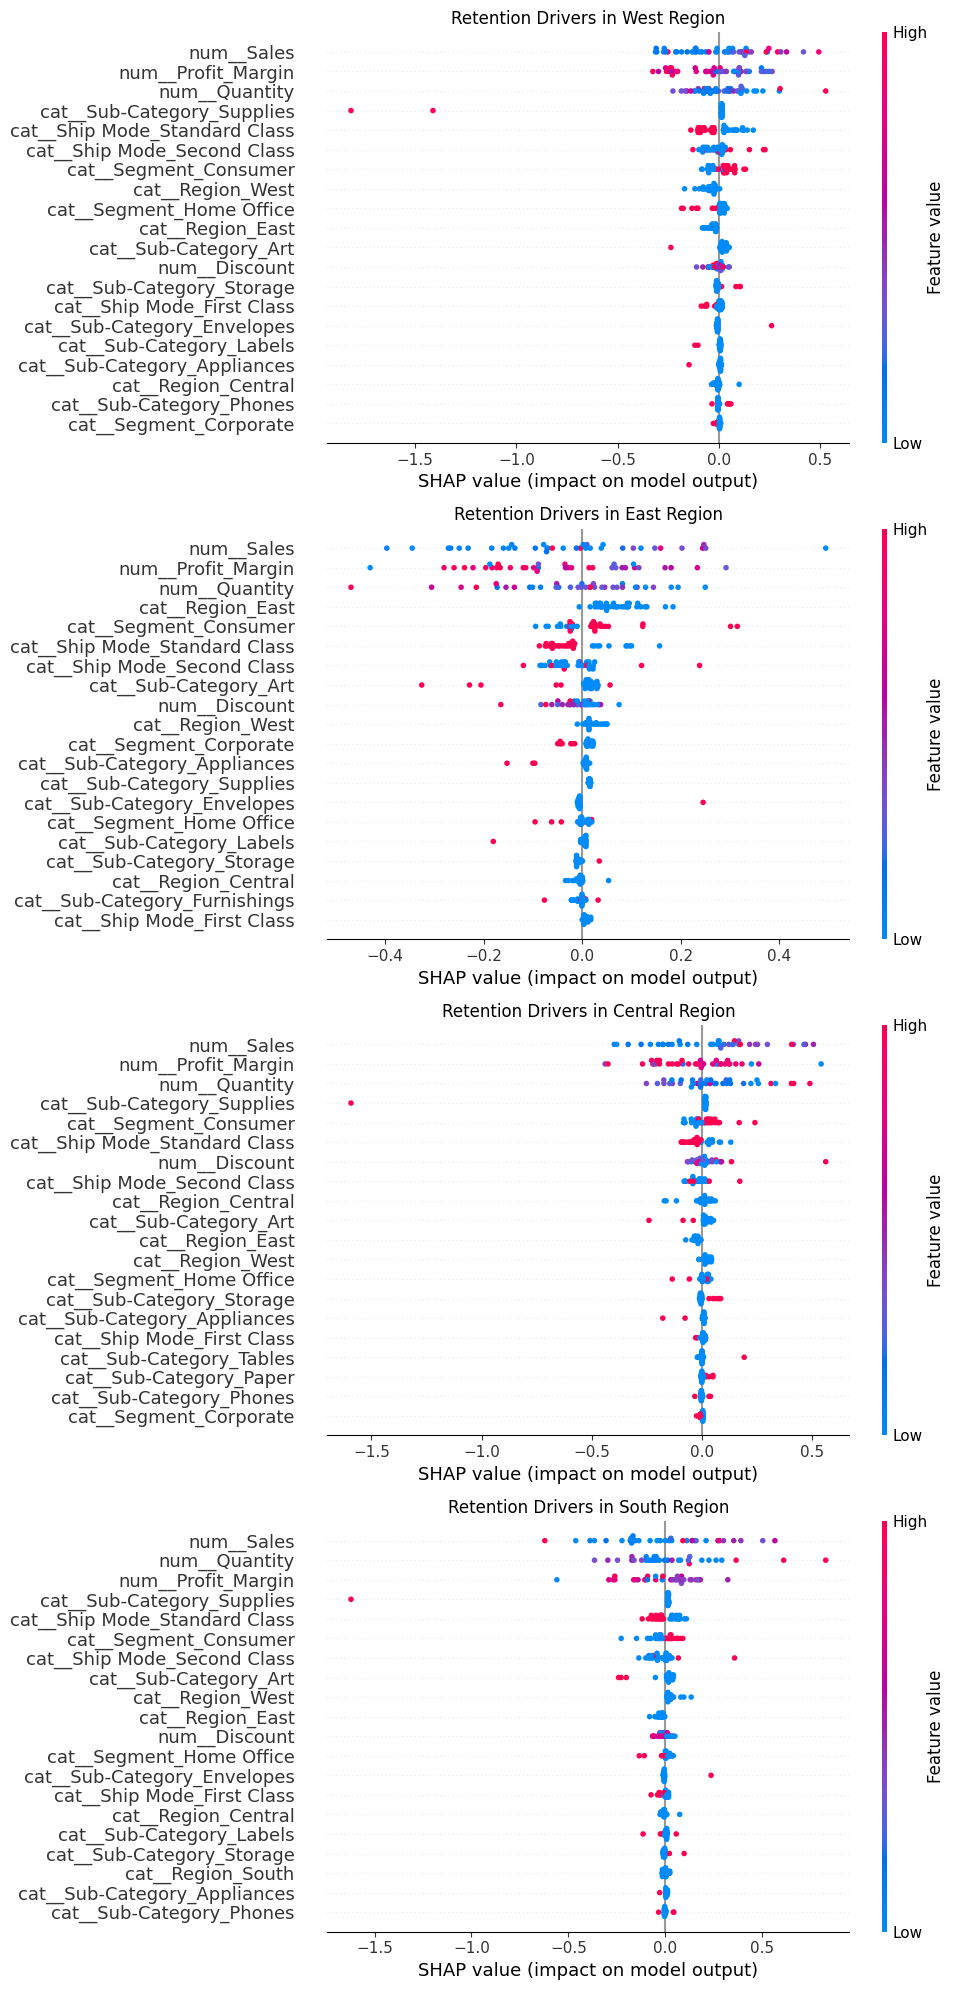

In [10]:
regions = final_df['Region'].unique()
fig, axes = plt.subplots(len(regions), 1, figsize=(10, 20))

for i, region in enumerate(regions):
    # 1. 筛选该地区的数据
    region_mask = (X_valid['Region'] == region)
    X_region = X_valid_transformed[region_mask.values]
    
    # 2. 计算该地区的 SHAP
    region_shap_values = explainer.shap_values(X_region)
    
    # 3. 画图 (每个地区画一个 Summary Plot)
    plt.sca(axes[i])
    axes[i].set_title(f"Retention Drivers in {region} Region")
    shap.summary_plot(region_shap_values, X_region, feature_names=feature_names, show=False, plot_size=None)

plt.tight_layout()
plt.show()

--- 各地区‘留存基因’对比表 ---
         is_retained  Discount  Profit_Margin       Sales   Quantity
Region                                                              
East        0.458937  0.189899       0.161882  460.000435   7.599034
Central     0.435897  0.282680      -0.108411  438.060063  12.756672
South       0.402878  0.135723       0.155740  771.449604   8.805755
West        0.396825  0.129789       0.216010  444.448756   8.948984


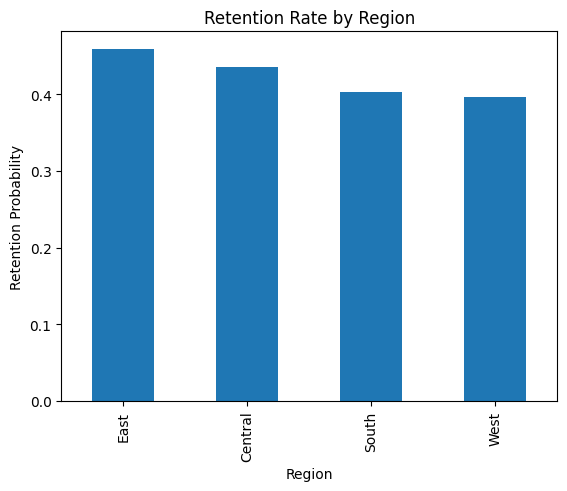

In [11]:
# 计算不同地区的关键特征指标
regional_comparison = final_df.groupby('Region').agg({
    'is_retained': 'mean',        # 复购率（最重要！）
    'Discount': 'mean',           # 平均折扣
    'Profit_Margin': 'mean',      # 平均利润率
    'Sales': 'mean',              # 平均客单价
    'Quantity': 'mean'            # 平均采购量
}).sort_values(by='is_retained', ascending=False)

print("--- 各地区‘留存基因’对比表 ---")
print(regional_comparison)

# 画个简单的条形图
regional_comparison['is_retained'].plot(kind='bar', title='Retention Rate by Region')
plt.ylabel('Retention Probability')
plt.show()

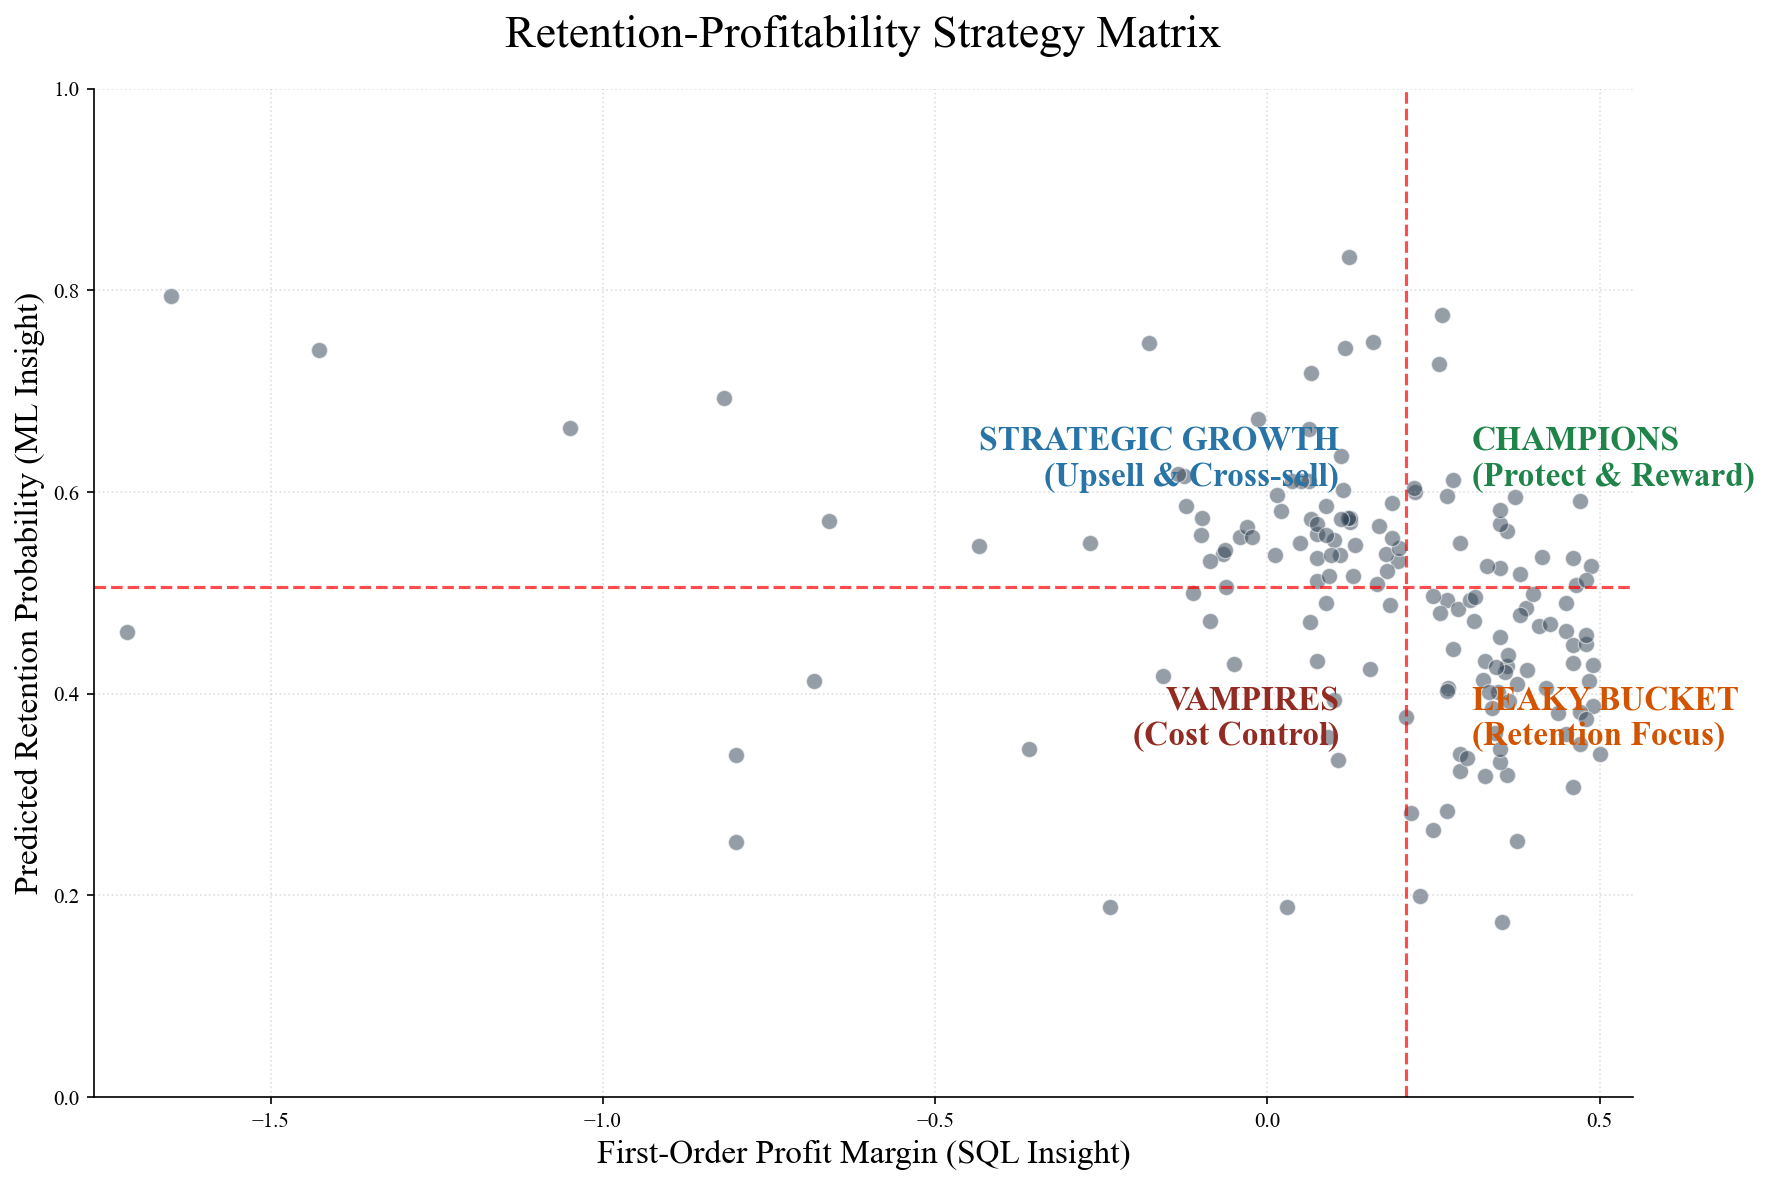

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import rcParams

# --- 设置字体为 Times New Roman ---
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

# 1. 准备绘图数据
# 获取验证集的预测概率 (Probability of class 1)
y_probs = clf.predict_proba(X_valid)[:, 1]

# 创建一个分析用的 DataFrame
plot_df = pd.DataFrame({
    'Profit_Margin': X_valid['Profit_Margin'],
    'Retention_Probability': y_probs
})

# 2. 定义象限的中轴线 (使用中位数或业务基准)
margin_mid = plot_df['Profit_Margin'].median()
prob_mid = plot_df['Retention_Probability'].median()

# 3. 开始绘图
plt.figure(figsize=(12, 8), dpi=150)

# 绘制散点图 (使用渐变色表示密集程度)
sns.scatterplot(data=plot_df, x='Profit_Margin', y='Retention_Probability', 
                alpha=0.5, s=60, color='#2c3e50', edgecolor='w')

# 绘制象限分割线
plt.axvline(x=margin_mid, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(y=prob_mid, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# 4. 添加象限标注 (Strategy Labels)
# 注意：坐标位置可以根据你的数据分布微调
plt.text(margin_mid + 0.1, prob_mid + 0.1, 'CHAMPIONS\n(Protect & Reward)', 
         fontsize=16, fontweight='bold', color='#1e8449', ha='left')

plt.text(margin_mid - 0.1, prob_mid + 0.1, 'STRATEGIC GROWTH\n(Upsell & Cross-sell)', 
         fontsize=16, fontweight='bold', color='#2874a6', ha='right')

plt.text(margin_mid + 0.1, prob_mid - 0.1, 'LEAKY BUCKET\n(Retention Focus)', 
         fontsize=16, fontweight='bold', color='#d35400', ha='left', va='top')

plt.text(margin_mid - 0.1, prob_mid - 0.1, 'VAMPIRES\n(Cost Control)', 
         fontsize=16, fontweight='bold', color='#922b21', ha='right', va='top')

# 5. 修饰图表
plt.title('Retention-Profitability Strategy Matrix', fontsize=22, pad=20)
plt.xlabel('First-Order Profit Margin (SQL Insight)', fontsize=16)
plt.ylabel('Predicted Retention Probability (ML Insight)', fontsize=16)

# 设置坐标轴范围 (根据你的 Margin 范围调整，比如 -0.5 到 0.5)
plt.xlim(plot_df['Profit_Margin'].min() - 0.05, plot_df['Profit_Margin'].max() + 0.05)
plt.ylim(0, 1)

plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()